In [1]:
#!/usr/bin/env python3
"""
=============================================================================
SUBCLUSTER vs DONOR-LEVEL DISCREPANCY ANALYSIS
=============================================================================
Critical question: Why do subcluster means and donor means disagree?

v14 manuscript: subcluster-level means (each subcluster = 1 data point)
  → NLRP3 showed IT elevation
  → IL1B showed IT elevation
  → "Inflammasome paradox" narrative built on this

Donor validation: donor-level means (each donor = 1 data point)
  → NLRP3: -4%, p=0.294 (NS)
  → IL1B: -4.7%, p=0.409 (NS)
  → paradox "collapsed"

HYPOTHESIS: The discrepancy may arise from COMPOSITION EFFECTS
  If IT has proportionally more cells in inflammasome-high subclusters,
  the subcluster-weighted mean increases even if per-donor expression
  doesn't change. This is Simpson's paradox in biology.

ANALYSIS PLAN:
  1. Reproduce subcluster-level means (as used in v14)
  2. Compute donor-level means (as in validation)
  3. Decompose: composition effect vs expression effect
  4. Save all results as CSV
  5. Determine if inflammasome paradox is truly dead or reframeable
=============================================================================
"""

!pip install -q scanpy leidenalg pyscenic gseapy openpyxl

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import scipy.sparse as sp
import os
import warnings
warnings.filterwarnings('ignore')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 136.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 123.4 MB/s eta 0:00:00
   ━━━━━

In [2]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# SETUP
# ============================================================
DATA_PATH = '/content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad'
SAVE_DIR = '/content/drive/MyDrive/ITLAS/results/task3_donor_validation/figures'
CSV_DIR = '/content/drive/MyDrive/ITLAS/results/task3_donor_validation/csv'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

print("Loading dataset...")
adata = sc.read_h5ad(DATA_PATH)
print(f"Dataset: {adata.shape[0]} cells, {adata.shape[1]} genes")


Loading dataset...
Dataset: 243000 cells, 24452 genes
Subcluster columns found: ['IT_cluster_21', 'IT_cluster_23', 'IT_cluster_25', 'gut2021_subcluster', 'gut2021_subcluster_v2']
All obs columns: ['sample', 'tissue', 'Stage', 'IT_cluster_21', 'IT_cluster_23', 'IT_cluster_25', 'IT_nk_collapse', 'IT_IT_signature', 'GSM_ID', 'IT_score_v2', 'IT_score_v3', 'IT_score_v4', 'IT_signature_final', 'IT_like', 'PW_mTOR_signaling', 'PW_glycolysis', 'PW_oxidative_phosphorylation', 'PW_nk_cell_cytotoxicity', 'PW_il15_signaling', 'PW_b_cell_differentiation', 'leiden', 'gut2021_subcluster', 'major_lineage', 'gut2021_subcluster_v2', 'TCR_clone.id', 'TCR_v_gene.x', 'TCR_j_gene.x', 'TCR_cdr3_nt.x', 'TCR_CType', 'BCR_clone.id', 'BCR_v_gene', 'BCR_j_gene', 'BCR_cdr3_nt', 'BCR_CType']


In [17]:
# donor_id: GSM5519467_P190604_Blood_1 → P190604
adata.obs['donor_id'] = adata.obs['sample'].astype(str).apply(
    lambda x: x.split('_')[1] if len(x.split('_')) >= 2 else x)

# sample_id: globally unique
adata.obs['sample_id'] = adata.obs['Stage'].astype(str) + '_' + adata.obs['donor_id'].astype(str)

# Quick check
print(f"Donors: {adata.obs['donor_id'].nunique()}")
for s in STAGE_ORDER:
    n = adata.obs[adata.obs['Stage']==s]['sample_id'].nunique()
    print(f"  {s}: n={n} sample_ids")

STAGE_ORDER = ['NL', 'IT', 'IA', 'AR', 'CR']
STAGE_COLORS = {'NL': 'forestgreen', 'IT': 'crimson', 'IA': 'darkorange',
                'AR': 'royalblue', 'CR': 'purple'}
np.random.seed(42)

LINEAGES = ['NK', 'CD8_T', 'CD4_T', 'Myeloid', 'B', 'PlasmaB']

# Check what subcluster column is called
sub_cols = [c for c in adata.obs.columns if 'sub' in c.lower() or 'cluster' in c.lower()]
print(f"Subcluster columns found: {sub_cols}")
print(f"All obs columns: {list(adata.obs.columns)}")


Donors: 23
  NL: n=6 sample_ids
  IT: n=6 sample_ids
  IA: n=5 sample_ids
  AR: n=3 sample_ids
  CR: n=3 sample_ids
Subcluster columns found: ['IT_cluster_21', 'IT_cluster_23', 'IT_cluster_25', 'gut2021_subcluster', 'gut2021_subcluster_v2']
All obs columns: ['sample', 'tissue', 'Stage', 'IT_cluster_21', 'IT_cluster_23', 'IT_cluster_25', 'IT_nk_collapse', 'IT_IT_signature', 'GSM_ID', 'IT_score_v2', 'IT_score_v3', 'IT_score_v4', 'IT_signature_final', 'IT_like', 'PW_mTOR_signaling', 'PW_glycolysis', 'PW_oxidative_phosphorylation', 'PW_nk_cell_cytotoxicity', 'PW_il15_signaling', 'PW_b_cell_differentiation', 'leiden', 'gut2021_subcluster', 'major_lineage', 'gut2021_subcluster_v2', 'TCR_clone.id', 'TCR_v_gene.x', 'TCR_j_gene.x', 'TCR_cdr3_nt.x', 'TCR_CType', 'BCR_clone.id', 'BCR_v_gene', 'BCR_j_gene', 'BCR_cdr3_nt', 'BCR_CType', 'donor_id', 'sample_id']


In [18]:
# ============================================================
# PART 0: Identify correct column names
# ============================================================
# Try to find the right columns
for col in adata.obs.columns:
    print(f"  {col}: {adata.obs[col].dtype}, nunique={adata.obs[col].nunique()}")

  sample: category, nunique=46
  tissue: category, nunique=2
  Stage: category, nunique=5
  IT_cluster_21: float64, nunique=242960
  IT_cluster_23: float64, nunique=240984
  IT_cluster_25: float64, nunique=114299
  IT_nk_collapse: float32, nunique=168875
  IT_IT_signature: float64, nunique=243000
  GSM_ID: category, nunique=46
  IT_score_v2: float64, nunique=243000
  IT_score_v3: float64, nunique=243000
  IT_score_v4: float64, nunique=242998
  IT_signature_final: float64, nunique=242998
  IT_like: category, nunique=2
  PW_mTOR_signaling: float32, nunique=30497
  PW_glycolysis: float32, nunique=208005
  PW_oxidative_phosphorylation: float32, nunique=237150
  PW_nk_cell_cytotoxicity: float32, nunique=137083
  PW_il15_signaling: float32, nunique=93432
  PW_b_cell_differentiation: float32, nunique=57564
  leiden: int64, nunique=24
  gut2021_subcluster: category, nunique=48
  major_lineage: category, nunique=7
  gut2021_subcluster_v2: category, nunique=59
  TCR_clone.id: category, nunique=4

In [8]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================
def get_donor_means(adata_sub, gene_name):
    if gene_name not in adata_sub.var_names:
        return None
    if sp.issparse(adata_sub.X):
        expr = adata_sub[:, gene_name].X.toarray().flatten()
    else:
        expr = adata_sub[:, gene_name].X.flatten()
    df = pd.DataFrame({
        'expression': expr,
        'Stage': adata_sub.obs['Stage'].astype(str).values,
        'donor_id': adata_sub.obs['donor_id'].astype(str).values
    })
    return df.groupby(['donor_id', 'Stage'])['expression'].mean().reset_index()

def donor_test(vals_a, vals_b):
    """Direct array input — no DataFrame filtering."""
    if len(vals_a) < 2 or len(vals_b) < 2:
        return {'n_a':len(vals_a),'n_b':len(vals_b),'change':'N/A',
                'consist':0,'total':0,'p':1.0}
    _, p_gt = mannwhitneyu(vals_a, vals_b, alternative='greater')
    _, p_lt = mannwhitneyu(vals_a, vals_b, alternative='less')
    if p_gt < p_lt:
        consist = sum(1 for a in vals_a for b in vals_b if a > b)
        p_use = p_gt
    else:
        consist = sum(1 for a in vals_a for b in vals_b if a < b)
        p_use = p_lt
    total = len(vals_a) * len(vals_b)
    ma, mb = np.mean(vals_a), np.mean(vals_b)
    ch = f"{(mb-ma)/ma*100:+.1f}%" if ma > 0 else "N/A"
    return {'n_a':len(vals_a),'n_b':len(vals_b),'change':ch,
            'consist':consist,'total':total,'p':p_use}

def plot_donor_dots(ax, donor_df, title, ylabel, stages=STAGE_ORDER):
    for i, stage in enumerate(stages):
        sd = donor_df[donor_df['Stage'] == stage]
        vals = []
        for _, row in sd.iterrows():
            jitter = np.random.uniform(-0.15, 0.15)
            ax.plot(i + jitter, row['expression'], 'o',
                    color=STAGE_COLORS[stage], markersize=8,
                    markeredgecolor='black', markeredgewidth=0.5, alpha=0.8)
            vals.append(row['expression'])
        if vals:
            ax.plot([i-0.25, i+0.25], [np.mean(vals)]*2, '-', color='black', lw=2.0)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(range(len(stages)))
    ax.set_xticklabels(stages, fontsize=10, fontweight='bold')
    for i, s in enumerate(stages):
        ax.get_xticklabels()[i].set_color(STAGE_COLORS[s])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def run_gene_battery(adata_sub, genes, lineage_name, comparisons, fig_title, save_name):
    """Run donor-level test for multiple genes across specified comparisons."""
    results = {}
    n_genes = len(genes)
    n_cols = min(4, n_genes)
    n_rows = (n_genes + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.5*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    fig.suptitle(fig_title, fontsize=13, fontweight='bold', y=1.0)

    for comp_name, (sa, sb) in comparisons.items():
        print(f"\n--- {lineage_name}: {comp_name} ---")
        print(f"  {'Gene':<12s} {sa+' mean':>10s} {sb+' mean':>10s} {'Change':>10s} "
              f"{'Direction':>12s} {'Consist':>10s} {'p-value':>10s}")
        print("  " + "-"*78)

        for idx, gene in enumerate(genes):
            donor_df = get_donor_means(adata_sub, gene)
            if donor_df is None:
                print(f"  {gene:<12s}: NOT FOUND")
                continue
            result = donor_test(donor_df, sa, sb)
            sig = " **" if result['p'] < 0.05 else " *" if result['p'] < 0.1 else ""
            change_str = f"{result['change']:+.1f}%" if abs(result['change']) < 9999 else "INF"
            print(f"  {gene:<12s} {result['va'].mean():>10.4f} {result['vb'].mean():>10.4f} "
                  f"{change_str:>10s} {result['direction']:>12s} "
                  f"{result['consist']}/{result['total']:>7} {result['p']:>10.3f}{sig}")
            results[f"{comp_name}_{gene}"] = result

            # Plot for primary comparison only
            if comp_name == list(comparisons.keys())[0]:
                r, c = idx // n_cols, idx % n_cols
                ax = axes[r, c]
                plot_donor_dots(ax, donor_df,
                                f'{gene}\n({sa}→{sb}: {change_str})',
                                f'{gene}')
                pcolor = 'darkred' if result['p'] < 0.05 else 'darkblue' if result['p'] < 0.1 else 'grey'
                label = f'{result["consist"]}/{result["total"]}, p={result["p"]:.3f}'
                ax.text(0.97, 0.95, label, transform=ax.transAxes, fontsize=8,
                        ha='right', va='top', color=pcolor, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                                  alpha=0.8, edgecolor='grey'))

    # Hide unused axes
    for idx in range(len(genes), n_rows * n_cols):
        r, c = idx // n_cols, idx % n_cols
        axes[r, c].set_visible(False)

    plt.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, f'{save_name}.png'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(SAVE_DIR, f'{save_name}.pdf'), bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_name}")
    return results

In [19]:
# ============================================================
# PART 1: THREE LEVELS OF ANALYSIS
# ============================================================
print("\n" + "="*80)
print("PART 1: THREE LEVELS OF AGGREGATION COMPARED")
print("="*80)
print("""
Level A: SUBCLUSTER means (v14 method)
  = For each subcluster in each stage, compute mean expression
  = Each subcluster is one data point
  = Stage mean = average of subcluster means
  = Problem: unequal cell counts per subcluster are ignored
  = Problem: one donor can dominate a subcluster

Level B: DONOR means (donor validation method)
  = For each donor in each stage, compute mean across ALL their cells
  = Each donor is one data point
  = Stage mean = average of donor means
  = Strength: controls for inter-individual variation
  = Problem: ignores subcluster structure

Level C: CELL-LEVEL means (simplest)
  = Pool all cells in a stage, compute mean
  = Each cell is one data point
  = Problem: donors with more cells dominate
  = This is what most scRNA-seq papers report
""")


PART 1: THREE LEVELS OF AGGREGATION COMPARED

Level A: SUBCLUSTER means (v14 method)
  = For each subcluster in each stage, compute mean expression
  = Each subcluster is one data point
  = Stage mean = average of subcluster means
  = Problem: unequal cell counts per subcluster are ignored
  = Problem: one donor can dominate a subcluster

Level B: DONOR means (donor validation method)  
  = For each donor in each stage, compute mean across ALL their cells
  = Each donor is one data point
  = Stage mean = average of donor means
  = Strength: controls for inter-individual variation
  = Problem: ignores subcluster structure

Level C: CELL-LEVEL means (simplest)
  = Pool all cells in a stage, compute mean
  = Each cell is one data point
  = Problem: donors with more cells dominate
  = This is what most scRNA-seq papers report



In [20]:
# ============================================================
# Key genes to investigate
# ============================================================
INVESTIGATE_GENES = ['NLRP3', 'IL1B', 'CASP1', 'PYCARD', 'AIM2', 'NLRC4',
                      'MEFV', 'GSDMD', 'IL18',
                      'LGALS9', 'TGFB1', 'TNFAIP3', 'IDO1', 'IL1RN']

# Get Myeloid subset
myeloid_mask = adata.obs['major_lineage'] == 'Myeloid'
adata_myeloid = adata[myeloid_mask].copy()

# Find subcluster column
subcluster_col = None
for col in ['subcluster', 'sub_cluster', 'cell_subtype', 'cell_type', 'leiden']:
    if col in adata_myeloid.obs.columns:
        subcluster_col = col
        break

if subcluster_col is None:
    # Try to find a column with many unique values within myeloid
    for col in adata_myeloid.obs.columns:
        if adata_myeloid.obs[col].nunique() > 5 and adata_myeloid.obs[col].nunique() < 100:
            if 'type' in col.lower() or 'cluster' in col.lower() or 'annot' in col.lower():
                subcluster_col = col
                break

print(f"\nUsing subcluster column: {subcluster_col}")
if subcluster_col:
    print(f"Myeloid subclusters: {adata_myeloid.obs[subcluster_col].unique()}")


Using subcluster column: leiden
Myeloid subclusters: [17  3  0 20  2 22 23 15 13  7  5  9 14]


In [26]:
# ============================================================
# COMPUTE THREE LEVELS
# ============================================================
print("\n" + "="*80)
print("COMPUTING THREE LEVELS FOR ALL GENES")
print("="*80)

results_all = []

for gene in INVESTIGATE_GENES:
    if gene not in adata_myeloid.var_names:
        print(f"  {gene}: NOT FOUND")
        continue

    if sp.issparse(adata_myeloid.X):
        expr = adata_myeloid[:, gene].X.toarray().flatten()
    else:
        expr = adata_myeloid[:, gene].X.flatten()

    df = pd.DataFrame({
        'expression': expr,
        'Stage': adata_myeloid.obs['Stage'].astype(str).values,
        'donor_id': adata_myeloid.obs['donor_id'].astype(str).values,
    })
    if subcluster_col:
        df['subcluster'] = adata_myeloid.obs[subcluster_col].astype(str).values

    for stage in STAGE_ORDER:
        sd = df[df['Stage'] == stage]
        if len(sd) == 0:
            continue

        # Level A: Subcluster means
        if subcluster_col:
            sub_means = sd.groupby('subcluster')['expression'].mean()
            level_a = sub_means.mean()
            level_a_n = len(sub_means)
        else:
            level_a = np.nan
            level_a_n = 0

        # Level B: Donor means
        donor_means = sd.groupby('donor_id')['expression'].mean()
        level_b = donor_means.mean()
        level_b_n = len(donor_means)

        # Level C: Cell-level mean
        level_c = sd['expression'].mean()
        level_c_n = len(sd)

        results_all.append({
            'gene': gene,
            'stage': stage,
            'subcluster_mean': level_a,
            'n_subclusters': level_a_n,
            'donor_mean': level_b,
            'n_donors': level_b_n,
            'cell_mean': level_c,
            'n_cells': level_c_n,
        })

results_df = pd.DataFrame(results_all)


COMPUTING THREE LEVELS FOR ALL GENES


In [27]:
# ============================================================
# PRINT COMPARISON TABLE
# ============================================================
print("\n" + "="*80)
print("THREE-LEVEL COMPARISON: NL vs IT (Myeloid)")
print("="*80)

print(f"\n{'Gene':<10s} | {'Subcluster mean':>30s} | {'Donor mean':>30s} | {'Cell mean':>30s}")
print(f"{'':10s} | {'NL':>8s} {'IT':>8s} {'Chg%':>8s} | {'NL':>8s} {'IT':>8s} {'Chg%':>8s} | {'NL':>8s} {'IT':>8s} {'Chg%':>8s}")
print("-" * 105)

for gene in INVESTIGATE_GENES:
    gd = results_df[results_df['gene'] == gene]
    nl_row = gd[gd['stage'] == 'NL']
    it_row = gd[gd['stage'] == 'IT']

    if len(nl_row) == 0 or len(it_row) == 0:
        continue

    nl = nl_row.iloc[0]
    it = it_row.iloc[0]

    def pct(a, b):
        if a > 0:
            return f"{(b-a)/a*100:+.1f}%"
        return "INF"

    print(f"  {gene:<10s} | {nl['subcluster_mean']:>8.4f} {it['subcluster_mean']:>8.4f} "
          f"{pct(nl['subcluster_mean'], it['subcluster_mean']):>8s} | "
          f"{nl['donor_mean']:>8.4f} {it['donor_mean']:>8.4f} "
          f"{pct(nl['donor_mean'], it['donor_mean']):>8s} | "
          f"{nl['cell_mean']:>8.4f} {it['cell_mean']:>8.4f} "
          f"{pct(nl['cell_mean'], it['cell_mean']):>8s}")



THREE-LEVEL COMPARISON: NL vs IT (Myeloid)

Gene       |                Subcluster mean |                     Donor mean |                      Cell mean
           |       NL       IT     Chg% |       NL       IT     Chg% |       NL       IT     Chg%
---------------------------------------------------------------------------------------------------------
  NLRP3      |   0.2745   0.1479   -46.1% |   0.3758   0.3605    -4.0% |   0.2303   0.3451   +49.9%
  IL1B       |   0.2565   0.2749    +7.2% |   0.7305   0.6965    -4.7% |   0.2411   0.4970  +106.2%
  CASP1      |   0.3477   0.6035   +73.6% |   0.7117   1.1295   +58.7% |   0.7846   1.1558   +47.3%
  PYCARD     |   0.7652   0.8775   +14.7% |   1.4325   1.7280   +20.6% |   1.5050   1.7668   +17.4%
  AIM2       |   0.0090   0.0388  +332.0% |   0.0118   0.0625  +430.7% |   0.0105   0.0678  +547.3%
  NLRC4      |   0.0381   0.0637   +67.2% |   0.0804   0.1462   +82.0% |   0.1009   0.1404   +39.1%
  MEFV       |   0.0688   0.1635  +137.6%

In [31]:
# ============================================================
# DECOMPOSITION: WHY DO LEVELS DISAGREE?
# ============================================================
print("\n" + "="*80)
print("DECOMPOSITION: WHY DO SUBCLUSTER AND DONOR LEVELS DISAGREE?")
print("="*80)

if subcluster_col:
    print("\n--- Myeloid subcluster composition by stage ---")

    # For each gene, decompose into composition and expression effects
    df_full = pd.DataFrame({
        'Stage': adata_myeloid.obs['Stage'].astype(str).values,
        'donor_id': adata_myeloid.obs['donor_id'].astype(str).values,
        'subcluster': adata_myeloid.obs[subcluster_col].astype(str).values,
    })

    # Subcluster composition (% of cells per subcluster per stage)
    comp = df_full.groupby(['Stage', 'subcluster']).size().reset_index(name='count')
    stage_totals = df_full.groupby('Stage').size().reset_index(name='total')
    comp = comp.merge(stage_totals, on='Stage')
    comp['pct'] = comp['count'] / comp['total'] * 100

    print("\nSubcluster composition (% of myeloid cells):")
    pivot = comp.pivot_table(index='subcluster', columns='Stage', values='pct', fill_value=0)
    if 'NL' in pivot.columns and 'IT' in pivot.columns:
        pivot = pivot.reindex(columns=[s for s in STAGE_ORDER if s in pivot.columns])
        print(pivot.round(1).to_string())

    # Donor composition (how many cells per donor per subcluster)
    print("\n--- Donor cell count per subcluster (NL vs IT) ---")
    for stage in ['NL', 'IT']:
        print(f"\n{stage}:")
        sd = df_full[df_full['Stage'] == stage]
        donor_sub = sd.groupby(['donor_id', 'subcluster']).size().reset_index(name='n')
        pivot_ds = donor_sub.pivot_table(index='donor_id', columns='subcluster',
                                          values='n', fill_value=0)
        print(pivot_ds.to_string())


DECOMPOSITION: WHY DO SUBCLUSTER AND DONOR LEVELS DISAGREE?

--- Myeloid subcluster composition by stage ---

Subcluster composition (% of myeloid cells):
Stage         NL    IT    IA    AR    CR
subcluster                              
0            0.0   0.1   0.0   0.0   0.0
13           0.0   0.2   0.0   0.0   0.6
14           0.0   0.0   0.0   0.0   0.0
15           0.0   0.0   0.0   0.0   0.0
17          12.2  11.7  16.2  12.9  11.7
2            0.1   0.1   0.1   0.0   0.0
20           8.4  16.7   2.9   4.5   4.0
22           0.0   1.9   3.1   4.2   9.0
23           0.0   0.0   0.0   0.1   0.0
3           79.2  69.2  77.6  78.3  74.4
5            0.0   0.0   0.0   0.0   0.0
7            0.0   0.0   0.0   0.0   0.0
9            0.0   0.0   0.0   0.0   0.4

--- Donor cell count per subcluster (NL vs IT) ---

NL:
subcluster    0   15     17    2    20   23       3
donor_id                                           
D528848     1.0  0.0    5.0  0.0  54.0  0.0    20.0
D529074     0.0 

In [32]:
# ============================================================
# KEY ANALYSIS: Per-subcluster expression NL vs IT
# ============================================================
print("\n" + "="*80)
print("PER-SUBCLUSTER EXPRESSION: NL vs IT for key genes")
print("This reveals WHERE the change happens (which subclusters)")
print("="*80)

for gene in ['NLRP3', 'IL1B', 'CASP1', 'AIM2', 'LGALS9', 'TGFB1']:
    if gene not in adata_myeloid.var_names:
        continue

    if sp.issparse(adata_myeloid.X):
        expr = adata_myeloid[:, gene].X.toarray().flatten()
    else:
        expr = adata_myeloid[:, gene].X.flatten()

    expr_df = pd.DataFrame({
        'expression': expr,
        'Stage': adata_myeloid.obs['Stage'].astype(str).values,
        'subcluster': adata_myeloid.obs[subcluster_col].astype(str).values,
    })

    print(f"\n--- {gene} per subcluster ---")
    sub_stage = expr_df.groupby(['subcluster', 'Stage'])['expression'].agg(
        ['mean', 'count']).reset_index()

    pivot_expr = sub_stage.pivot_table(index='subcluster', columns='Stage',
                                        values='mean', fill_value=0)
    if 'NL' in pivot_expr.columns and 'IT' in pivot_expr.columns:
        pivot_expr = pivot_expr.reindex(columns=[s for s in STAGE_ORDER if s in pivot_expr.columns])
        pivot_expr['NL→IT_chg'] = ((pivot_expr['IT'] - pivot_expr['NL']) /
                                    pivot_expr['NL'].replace(0, np.nan) * 100)
        print(pivot_expr.round(4).to_string())


PER-SUBCLUSTER EXPRESSION: NL vs IT for key genes
This reveals WHERE the change happens (which subclusters)

--- NLRP3 per subcluster ---
Stage           NL      IT      IA      AR      CR   NL→IT_chg
subcluster                                                    
0           0.0000  0.0000  0.0000  0.0000  0.0000         NaN
13          0.0000  0.0000  0.0000  0.0000  0.0534         NaN
14          0.0000  0.0000  0.0000  0.0000  0.0000         NaN
15          1.0132  0.0000  0.0000  0.0000  0.0000 -100.000000
17          0.0843  0.1316  0.1027  0.0982  0.1997   56.190701
2           0.0000  0.0000  0.0000  0.0000  0.0000         NaN
20          0.6115  0.5581  0.5947  0.7090  0.6042   -8.732000
22          0.0000  0.4606  0.6759  0.7211  0.7643         NaN
23          0.0000  0.0000  0.0000  0.0000  0.0000         NaN
3           0.2124  0.3288  0.3117  0.2955  0.2978   54.774502
5           0.0000  0.0000  0.0000  0.0000  0.0000         NaN
7           0.0000  0.0000  0.0000  0.0000

In [33]:
# ============================================================
# PART 3: DONOR-LEVEL DETAILED TABLE (for CSV saving)
# ============================================================
print("\n" + "="*80)
print("SAVING DONOR-LEVEL RESULTS AS CSV")
print("="*80)

# Compute donor-level means for ALL genes, ALL lineages, ALL stages
all_donor_records = []

for lineage in LINEAGES:
    lin_mask = adata.obs['major_lineage'] == lineage
    adata_lin = adata[lin_mask]

    for gene in INVESTIGATE_GENES:
        if gene not in adata_lin.var_names:
            continue

        if sp.issparse(adata_lin.X):
            expr = adata_lin[:, gene].X.toarray().flatten()
        else:
            expr = adata_lin[:, gene].X.flatten()

        df = pd.DataFrame({
            'expression': expr,
            'Stage': adata_lin.obs['Stage'].astype(str).values,
            'donor_id': adata_lin.obs['donor_id'].astype(str).values,
        })

        donor_means = df.groupby(['donor_id', 'Stage'])['expression'].mean().reset_index()
        donor_means['lineage'] = lineage
        donor_means['gene'] = gene
        all_donor_records.append(donor_means)

donor_all_df = pd.concat(all_donor_records, ignore_index=True)
donor_csv_path = os.path.join(CSV_DIR, 'donor_level_expression_all.csv')
donor_all_df.to_csv(donor_csv_path, index=False)
print(f"Saved: {donor_csv_path}")
print(f"  Shape: {donor_all_df.shape}")


SAVING DONOR-LEVEL RESULTS AS CSV
Saved: /content/drive/MyDrive/ITLAS/results/task3_donor_validation/csv/donor_level_expression_all.csv
  Shape: (1932, 5)


In [34]:
# ============================================================
# DONOR-LEVEL STATISTICAL RESULTS — CSV
# ============================================================
stat_records = []
comparisons = [('NL','IT'), ('NL','CR'), ('IT','IA'), ('IA','AR'), ('NL','IA')]

for lineage in LINEAGES:
    lin_mask = adata.obs['major_lineage'] == lineage
    adata_lin = adata[lin_mask]

    for gene in INVESTIGATE_GENES:
        if gene not in adata_lin.var_names:
            continue

        if sp.issparse(adata_lin.X):
            expr = adata_lin[:, gene].X.toarray().flatten()
        else:
            expr = adata_lin[:, gene].X.flatten()

        df = pd.DataFrame({
            'expression': expr,
            'Stage': adata_lin.obs['Stage'].astype(str).values,
            'donor_id': adata_lin.obs['donor_id'].astype(str).values,
        })
        donor_means = df.groupby(['donor_id', 'Stage'])['expression'].mean().reset_index()

        for sa, sb in comparisons:
            va = donor_means[donor_means['Stage'] == sa]['expression'].values
            vb = donor_means[donor_means['Stage'] == sb]['expression'].values

            if len(va) < 2 or len(vb) < 2:
                continue

            _, p_gt = mannwhitneyu(va, vb, alternative='greater')
            _, p_lt = mannwhitneyu(va, vb, alternative='less')

            if p_gt < p_lt:
                consist = sum(1 for a in va for b in vb if a > b)
                direction = f'{sa}>{sb}'
                p_use = p_gt
            else:
                consist = sum(1 for a in va for b in vb if a < b)
                direction = f'{sb}>{sa}'
                p_use = p_lt

            total = len(va) * len(vb)
            change = (vb.mean() - va.mean()) / va.mean() * 100 if va.mean() > 0 else np.inf

            stat_records.append({
                'lineage': lineage,
                'gene': gene,
                'comparison': f'{sa}_vs_{sb}',
                'stage_a': sa,
                'stage_b': sb,
                'mean_a': va.mean(),
                'mean_b': vb.mean(),
                'pct_change': change,
                'direction': direction,
                'consistency': consist,
                'total_pairs': total,
                'consistency_pct': consist/total*100,
                'p_value': p_use,
                'significant_05': p_use < 0.05,
                'significant_10': p_use < 0.10,
            })

stat_df = pd.DataFrame(stat_records)
stat_csv_path = os.path.join(CSV_DIR, 'donor_level_statistics_all.csv')
stat_df.to_csv(stat_csv_path, index=False)
print(f"Saved: {stat_csv_path}")
print(f"  Shape: {stat_df.shape}")

# Quick summary of significant findings
print("\n--- SIGNIFICANT FINDINGS (p<0.05) ---")
sig = stat_df[stat_df['significant_05']].sort_values('p_value')
print(f"  Total significant: {len(sig)}/{len(stat_df)}")
for _, row in sig.iterrows():
    print(f"  {row['lineage']:10s} {row['gene']:10s} {row['comparison']:12s} "
          f"{row['pct_change']:+.1f}% {row['consistency']}/{row['total_pairs']} "
          f"p={row['p_value']:.3f}")

Saved: /content/drive/MyDrive/ITLAS/results/task3_donor_validation/csv/donor_level_statistics_all.csv
  Shape: (420, 15)

--- SIGNIFICANT FINDINGS (p<0.05) ---
  Total significant: 84/420
  Myeloid    LGALS9     NL_vs_IT     +74.8% 36/36 p=0.001
  PlasmaB    PYCARD     NL_vs_IT     +186.3% 36/36 p=0.001
  CD4_T      IL1RN      NL_vs_IA     +inf% 30/30 p=0.002
  Myeloid    PYCARD     NL_vs_IA     +33.5% 30/30 p=0.002
  Myeloid    TGFB1      NL_vs_IA     +72.6% 30/30 p=0.002
  Myeloid    LGALS9     NL_vs_IA     +86.4% 30/30 p=0.002
  PlasmaB    PYCARD     NL_vs_IA     +187.5% 30/30 p=0.002
  Myeloid    MEFV       NL_vs_IA     +142.5% 29/30 p=0.004
  Myeloid    CASP1      NL_vs_IA     +64.2% 29/30 p=0.004
  CD8_T      NLRC4      NL_vs_CR     +inf% 18/18 p=0.005
  CD4_T      IL1RN      NL_vs_CR     +inf% 18/18 p=0.005
  B          NLRP3      NL_vs_CR     +inf% 18/18 p=0.005
  B          IL1B       NL_vs_CR     +inf% 18/18 p=0.005
  B          MEFV       NL_vs_CR     +inf% 18/18 p=0.005
  N

In [35]:
# ============================================================
# PART 4: THE RECONCILIATION — Can inflammasome paradox survive?
# ============================================================
print("\n" + "="*80)
print("PART 4: INFLAMMASOME PARADOX — RECONCILIATION ANALYSIS")
print("="*80)

print("""
QUESTION: Is the inflammasome paradox truly dead, or is it a
COMPOSITION EFFECT that needs reframing?

Three scenarios:

Scenario A: "True Death"
  If subcluster composition does NOT change NL→IT, AND
  per-subcluster expression also shows no NLRP3/IL1B change
  → Paradox was pure statistical artifact
  → Must be deleted entirely

Scenario B: "Composition Rescue"
  If certain myeloid subclusters are enriched in IT, AND
  those subclusters are inflammasome-high
  → The paradox is REAL but it's a COMPOSITION effect
  → Reframe: "IT enriches for inflammasome-primed myeloid subtypes"
  → Still novel, still publishable, just different framing

Scenario C: "Subcluster-Specific"
  If specific subclusters show NLRP3/IL1B increase but others decrease
  → The paradox exists in specific subtypes, not pan-myeloid
  → Reframe: "Subtype-specific inflammasome activation"
  → Need to identify which subclusters drive it
""")


PART 4: INFLAMMASOME PARADOX — RECONCILIATION ANALYSIS

QUESTION: Is the inflammasome paradox truly dead, or is it a 
COMPOSITION EFFECT that needs reframing?

Three scenarios:

Scenario A: "True Death"
  If subcluster composition does NOT change NL→IT, AND
  per-subcluster expression also shows no NLRP3/IL1B change
  → Paradox was pure statistical artifact
  → Must be deleted entirely

Scenario B: "Composition Rescue"  
  If certain myeloid subclusters are enriched in IT, AND
  those subclusters are inflammasome-high
  → The paradox is REAL but it's a COMPOSITION effect
  → Reframe: "IT enriches for inflammasome-primed myeloid subtypes"
  → Still novel, still publishable, just different framing

Scenario C: "Subcluster-Specific"
  If specific subclusters show NLRP3/IL1B increase but others decrease
  → The paradox exists in specific subtypes, not pan-myeloid
  → Reframe: "Subtype-specific inflammasome activation"
  → Need to identify which subclusters drive it



In [36]:
# ============================================================
# PART 5: PER-DONOR, PER-SUBCLUSTER DECOMPOSITION
# ============================================================
print("\n" + "="*80)
print("PART 5: PER-DONOR, PER-SUBCLUSTER DECOMPOSITION")
print("       For NLRP3 and IL1B specifically")
print("="*80)

if subcluster_col:
    for gene in ['NLRP3', 'IL1B', 'CASP1', 'AIM2']:
        if gene not in adata_myeloid.var_names:
            continue

        if sp.issparse(adata_myeloid.X):
            expr = adata_myeloid[:, gene].X.toarray().flatten()
        else:
            expr = adata_myeloid[:, gene].X.flatten()

        full_df = pd.DataFrame({
            'expression': expr,
            'Stage': adata_myeloid.obs['Stage'].astype(str).values,
            'donor_id': adata_myeloid.obs['donor_id'].astype(str).values,
            'subcluster': adata_myeloid.obs[subcluster_col].astype(str).values,
        })

        print(f"\n{'='*60}")
        print(f"{gene}: Per-donor, per-subcluster mean expression")
        print(f"{'='*60}")

        for stage in ['NL', 'IT']:
            sd = full_df[full_df['Stage'] == stage]
            pivot = sd.groupby(['donor_id', 'subcluster'])['expression'].mean().reset_index()
            pivot_wide = pivot.pivot_table(index='donor_id', columns='subcluster',
                                            values='expression', fill_value=np.nan)
            print(f"\n{stage} (n={sd['donor_id'].nunique()} donors):")
            print(pivot_wide.round(4).to_string())

            # Also show cell counts
            count_pivot = sd.groupby(['donor_id', 'subcluster']).size().reset_index(name='n')
            count_wide = count_pivot.pivot_table(index='donor_id', columns='subcluster',
                                                  values='n', fill_value=0)
            print(f"\nCell counts:")
            print(count_wide.to_string())


PART 5: PER-DONOR, PER-SUBCLUSTER DECOMPOSITION
       For NLRP3 and IL1B specifically

NLRP3: Per-donor, per-subcluster mean expression

NL (n=6 donors):
subcluster    0      15      17    2      20   23       3
donor_id                                                 
D528848     0.0     NaN  0.0000  NaN  0.6472  NaN  0.0000
D529074     NaN     NaN  0.0000  NaN  0.1695  NaN  0.7631
D529351     NaN     NaN  0.0941  NaN  0.4314  0.0  0.1988
D529354     NaN  1.0132  0.0533  0.0  0.3175  NaN  0.2866
D529409     NaN     NaN  0.0000  0.0  0.8283  NaN  0.2048
Dhc570      NaN     NaN  0.0000  NaN  1.0647  NaN  0.0000

Cell counts:
subcluster    0   15     17    2    20   23       3
donor_id                                           
D528848     1.0  0.0    5.0  0.0  54.0  0.0    20.0
D529074     0.0  0.0    3.0  0.0   8.0  0.0     5.0
D529351     0.0  0.0  240.0  0.0  35.0  1.0  1135.0
D529354     0.0  1.0   33.0  1.0  38.0  0.0   287.0
D529409     0.0  0.0    5.0  1.0  42.0  0.0   427.0
Dh


PART 6: VISUALIZATION


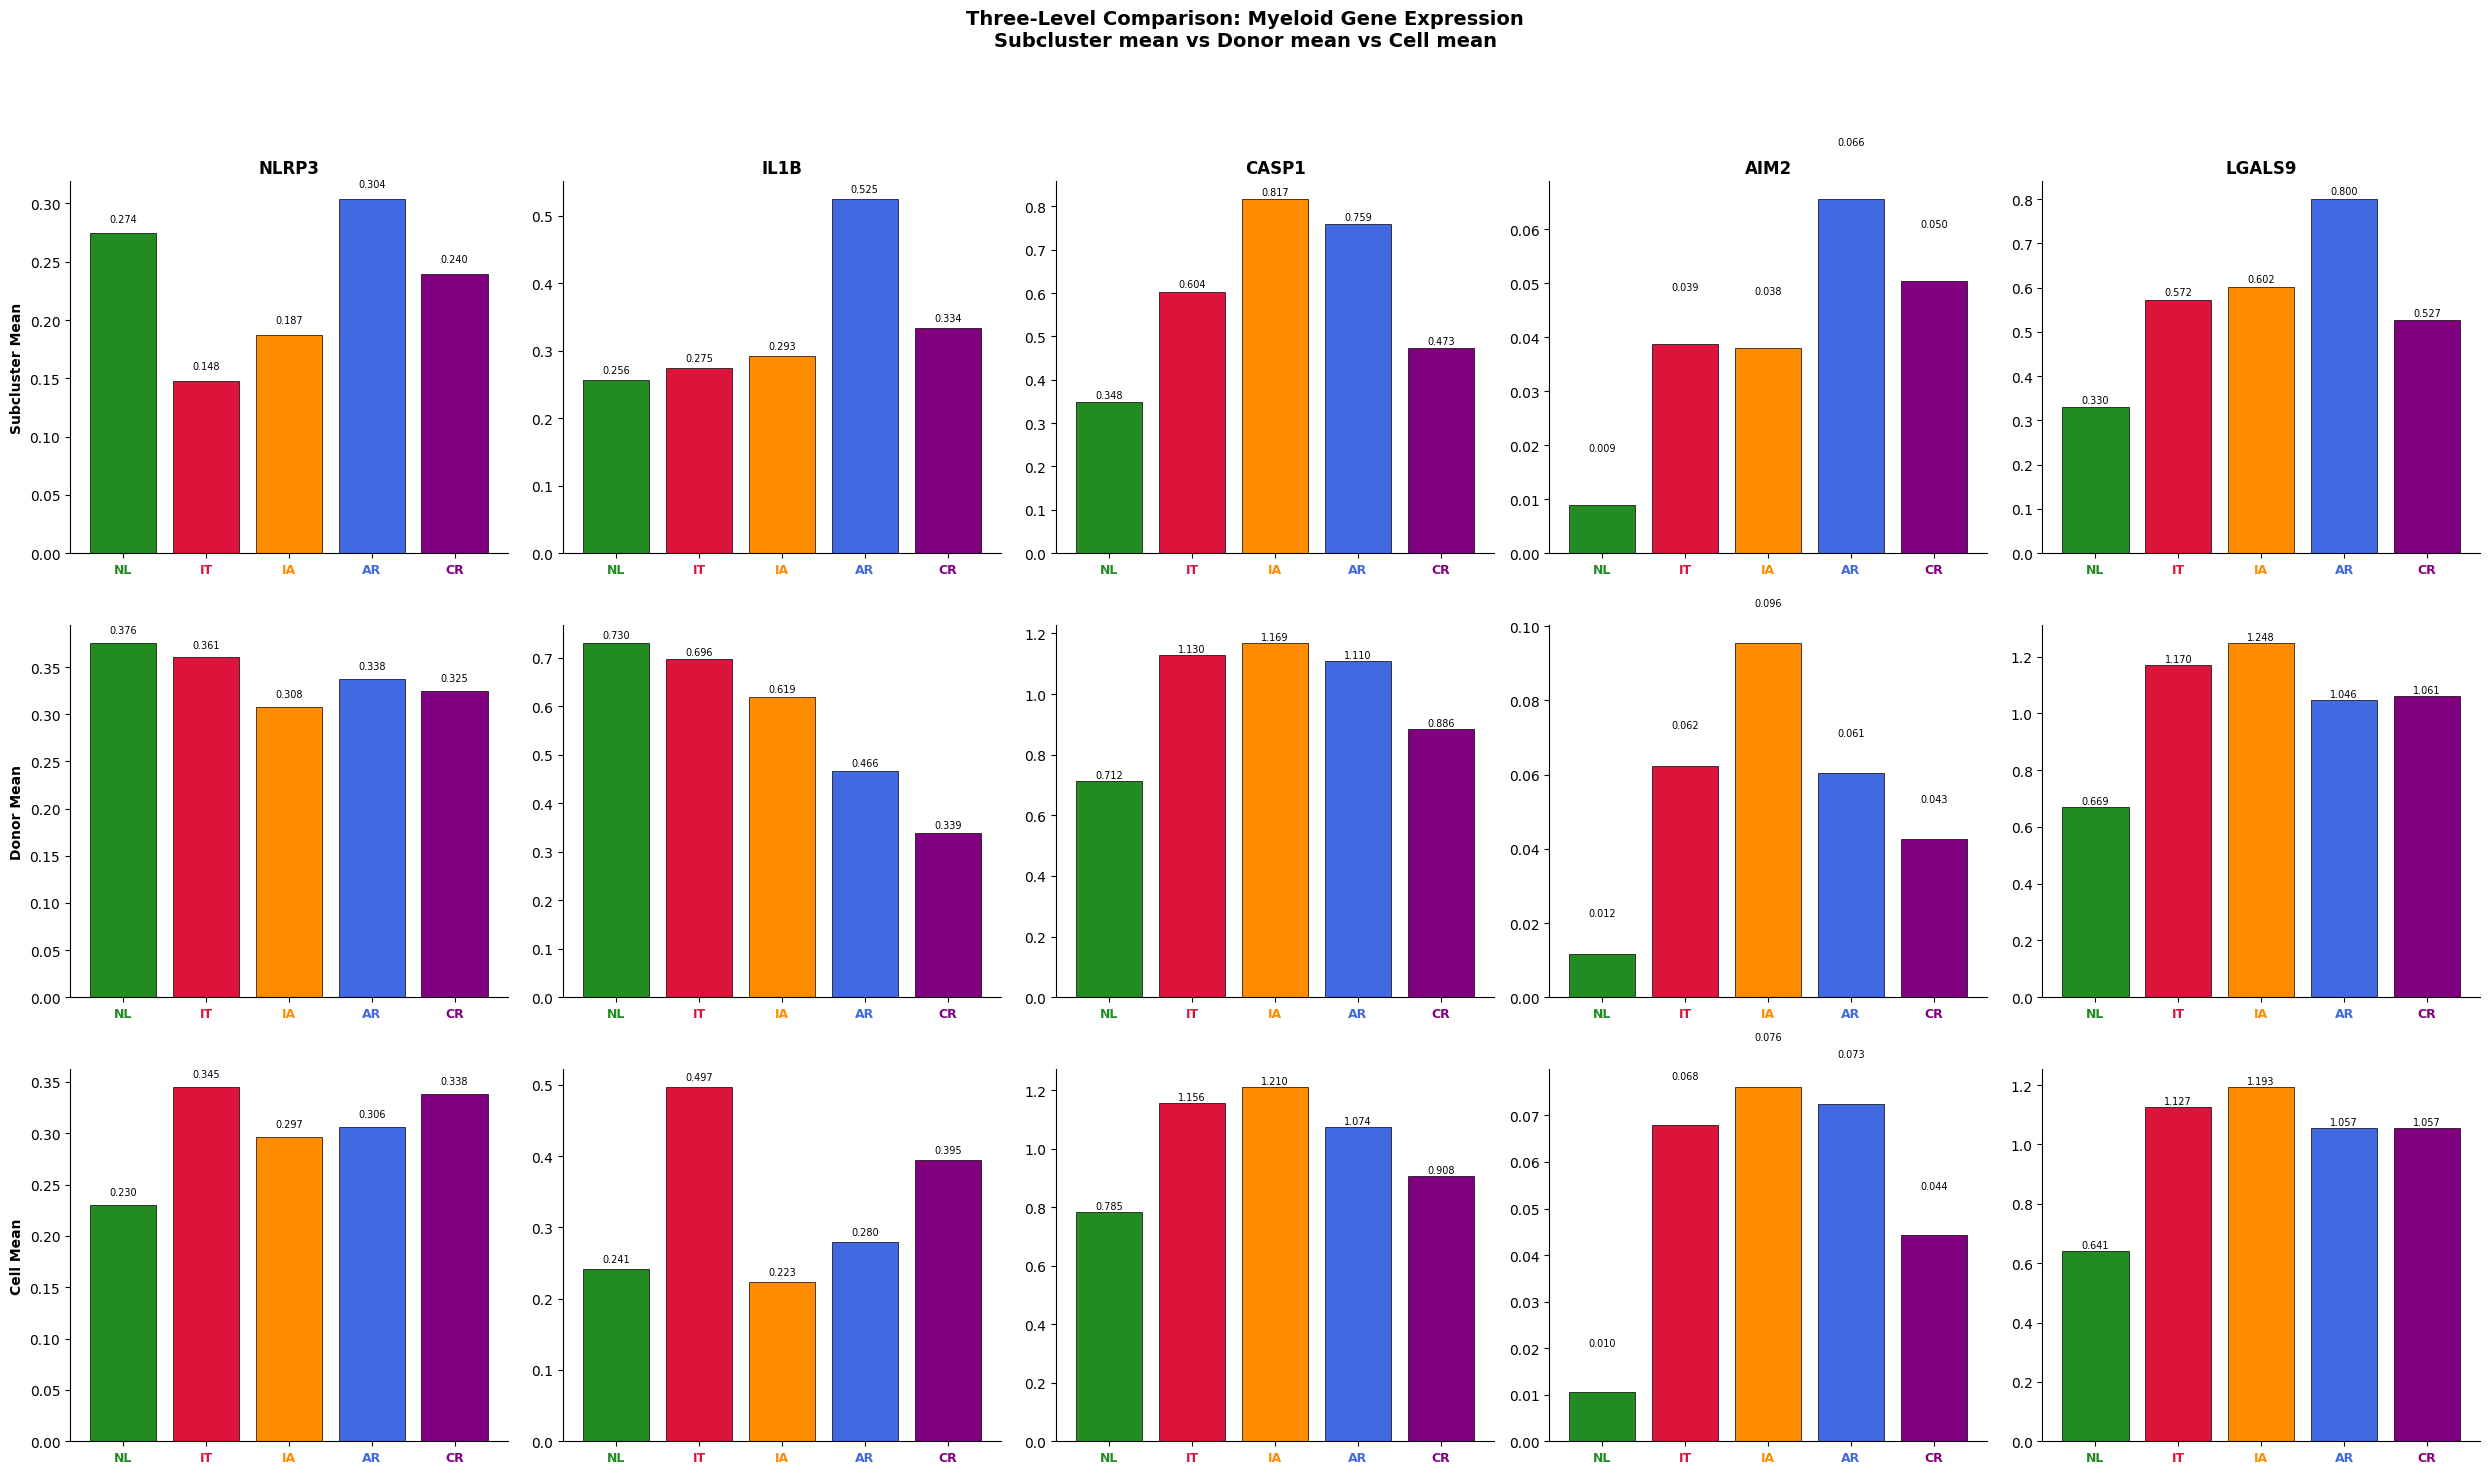

Saved: ThreeLevel_Comparison_Myeloid


In [37]:
# ============================================================
# PART 6: VISUALIZATION — Three levels side by side
# ============================================================
print("\n" + "="*80)
print("PART 6: VISUALIZATION")
print("="*80)

STAGE_COLORS = {'NL': 'forestgreen', 'IT': 'crimson', 'IA': 'darkorange',
                'AR': 'royalblue', 'CR': 'purple'}

fig, axes = plt.subplots(3, 5, figsize=(25, 15))
fig.suptitle('Three-Level Comparison: Myeloid Gene Expression\n'
             'Subcluster mean vs Donor mean vs Cell mean',
             fontsize=14, fontweight='bold')

plot_genes = ['NLRP3', 'IL1B', 'CASP1', 'AIM2', 'LGALS9']
level_names = ['Subcluster Mean', 'Donor Mean', 'Cell Mean']
level_keys = ['subcluster_mean', 'donor_mean', 'cell_mean']

for col_idx, gene in enumerate(plot_genes):
    gd = results_df[results_df['gene'] == gene]

    for row_idx, (level_name, level_key) in enumerate(zip(level_names, level_keys)):
        ax = axes[row_idx, col_idx]

        for i, stage in enumerate(STAGE_ORDER):
            sd = gd[gd['stage'] == stage]
            if len(sd) > 0:
                val = sd[level_key].values[0]
                ax.bar(i, val, color=STAGE_COLORS[stage], edgecolor='black', linewidth=0.5)
                ax.text(i, val + 0.01, f'{val:.3f}', ha='center', fontsize=7)

        ax.set_xticks(range(len(STAGE_ORDER)))
        ax.set_xticklabels(STAGE_ORDER, fontsize=9, fontweight='bold')
        for i, s in enumerate(STAGE_ORDER):
            ax.get_xticklabels()[i].set_color(STAGE_COLORS[s])

        if col_idx == 0:
            ax.set_ylabel(level_name, fontsize=10, fontweight='bold')
        if row_idx == 0:
            ax.set_title(gene, fontsize=12, fontweight='bold')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(os.path.join(SAVE_DIR, 'ThreeLevel_Comparison_Myeloid.png'),
            dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(SAVE_DIR, 'ThreeLevel_Comparison_Myeloid.pdf'),
            bbox_inches='tight')
plt.show()
print("Saved: ThreeLevel_Comparison_Myeloid")


In [38]:
# ============================================================
# SAVE COMPLETE THREE-LEVEL TABLE AS CSV
# ============================================================
results_df.to_csv(os.path.join(CSV_DIR, 'three_level_comparison_myeloid.csv'), index=False)
print(f"\nSaved: three_level_comparison_myeloid.csv")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nCSV files saved to: {CSV_DIR}")
print("  1. donor_level_expression_all.csv — Raw donor means for all genes/lineages")
print("  2. donor_level_statistics_all.csv — All statistical test results")
print("  3. three_level_comparison_myeloid.csv — Three-level comparison")
print("\nNext: Examine results to determine if inflammasome paradox survives as")
print("      composition effect (Scenario B) or must be fully retracted (Scenario A)")



Saved: three_level_comparison_myeloid.csv

ANALYSIS COMPLETE

CSV files saved to: /content/drive/MyDrive/ITLAS/results/task3_donor_validation/csv
  1. donor_level_expression_all.csv — Raw donor means for all genes/lineages
  2. donor_level_statistics_all.csv — All statistical test results
  3. three_level_comparison_myeloid.csv — Three-level comparison

Next: Examine results to determine if inflammasome paradox survives as
      composition effect (Scenario B) or must be fully retracted (Scenario A)
